# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

**Business Understanding:** From a business perspective, the Used Car Dealership is looking to identify the key factors that influence used car pricing. Gaining this insight will empower them to:

- **Handle Market Competition:** Set more competitive prices for their inventory
- **Improved Decision Making:** Make informed, data-backed decisions when sourcing high-demand vehicles
- **Customer Preferences:** Understand which vehicle attributes customers value most when making a purchase
- **Profitability:** Increase profitability by minimizing pricing errors and maximizing market alignment

The goal is to identify key drivers for used car prices:

- By training machine learning models on key predictors—such as vehicle year, mileage (odometer), size, fuel type, drivetrain, condition, and transmission, I aim to deliver accurate, data-driven pricing predictions.
- By leveraging predictive modeling to estimate used car prices using historical vehicle and sales data. This requires a supervised regression models, where the target or dependent variable is vehicle **price**.
- Techniques like feature selection, model interpretability, and algorithms such as Multiple Linear Regression, Ridge, and Lasso will help uncover the most influential features shaping pricing patterns in the used car market, enabling smarter strategy and competitive advantage.

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

In [236]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_selection import SelectFromModel, SequentialFeatureSelector
from sklearn.metrics import mean_squared_error, r2_score
from sklearn import set_config
from sklearn.preprocessing import LabelEncoder

set_config(display="diagram")

import pandas as pd
import plotly.express as px
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')


In [238]:
# 1. Initial Data Inspection, Read the vehicles csv file, load and preview the data 

data = pd.read_csv("vehicles.csv")
data.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [240]:
# See Data Types 
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

,id,price,year,odometer
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07


In [242]:
#Define Function - To get basic column stats

def describe_columns(df):
    desc = pd.DataFrame({
        'Null Count': df.isnull().sum(),
        'Non-Null Count': df.notnull().sum(),
        '% Null': round(df.isnull().mean() * 100, 2),
        'Unique Values': df.nunique(),
    })

    # Numeric-only columns
    numeric_cols = df.select_dtypes(include='number').columns

    # Get raw min/max for numeric columns
    min_vals = df[numeric_cols].min()
    max_vals = df[numeric_cols].max()

    # Format min/max values 
    desc['Min'] = min_vals.apply(lambda x: f"{x:,.0f}")
    desc['Max'] = max_vals.apply(lambda x: f"{x:,.0f}")

    # Format Quartiles
    quartiles = df[numeric_cols].quantile([0.25, 0.5, 0.75]).T
    quartiles.columns = ['25%', '50%', '75%']
    quartiles = quartiles.applymap(lambda x: f"{x:,.0f}")

    # Join quartiles and sort
    return desc.join(quartiles, how='left').sort_values(by='% Null', ascending=False)

#Call Function
describe_columns(data)

,Null Count,Non-Null Count,% Null,Unique Values,Min,Max,25%,50%,75%
size,306361,120519,71.77,4,NaN,NaN,NaN,NaN,NaN
cylinders,177678,249202,41.62,8,NaN,NaN,NaN,NaN,NaN
condition,174104,252776,40.79,6,NaN,NaN,NaN,NaN,NaN
VIN,161042,265838,37.73,118246,NaN,NaN,NaN,NaN,NaN
drive,130567,296313,30.59,3,NaN,NaN,NaN,NaN,NaN
paint_color,130203,296677,30.50,12,NaN,NaN,NaN,NaN,NaN
type,92858,334022,21.75,13,NaN,NaN,NaN,NaN,NaN
manufacturer,17646,409234,4.13,42,NaN,NaN,NaN,NaN,NaN
title_status,8242,418638,1.93,6,NaN,NaN,NaN,NaN,NaN
model,5277,421603,1.24,29649,NaN,NaN,NaN,NaN,NaN


In [244]:
# Check Other Data Quality Issues & Outliers

#Check Dupes
duplicate_count = data.duplicated().sum()
print(f"Duplicate Rows: {duplicate_count:,}")

# See how many entries are priced low or extremely high
print("Cars with price = $0:", (data['price'] == 0).sum())
print("Cars with price > $0 & < $1,000:", ((data['price'] > 0) & (data['price'] < 1000)).sum())
print("Cars with price > $100,000:", (data['price'] > 100000).sum())
print("Cars with price > $1 million:", (data['price'] > 1000000).sum())

# See how many cars are from before 1980
print("Cars with year before 1980:", (data['year'] < 1980).sum())
print("Cars with year greater than 1980:", (data['year'] > 1980).sum())

#Odo Outlier
# See how many entries are priced low or extremely high
print("Cars with odo greater than > 1,000,000:", (data['odometer'] > 1000000).sum())

# Top 20 frequent model variants
print(data['model'].value_counts(dropna=False).head(20))

Duplicate Rows: 0
Cars with price = $0: 32895
Cars with price > $0 & < $1,000: 13420
Cars with price > $100,000: 655
Cars with price > $1 million: 53
Cars with year before 1980: 8413
Cars with year greater than 1980: 416990
Cars with odo greater than > 1,000,000: 576
model
f-150             8009
NaN               5277
silverado 1500    5140
1500              4211
camry             3135
silverado         3023
accord            2969
wrangler          2848
civic             2799
altima            2779
escape            2746
2500              2687
tacoma            2582
explorer          2499
grand cherokee    2489
corolla           2241
mustang           2225
fusion            1979
equinox           1972
cr-v              1930
Name: count, dtype: int64


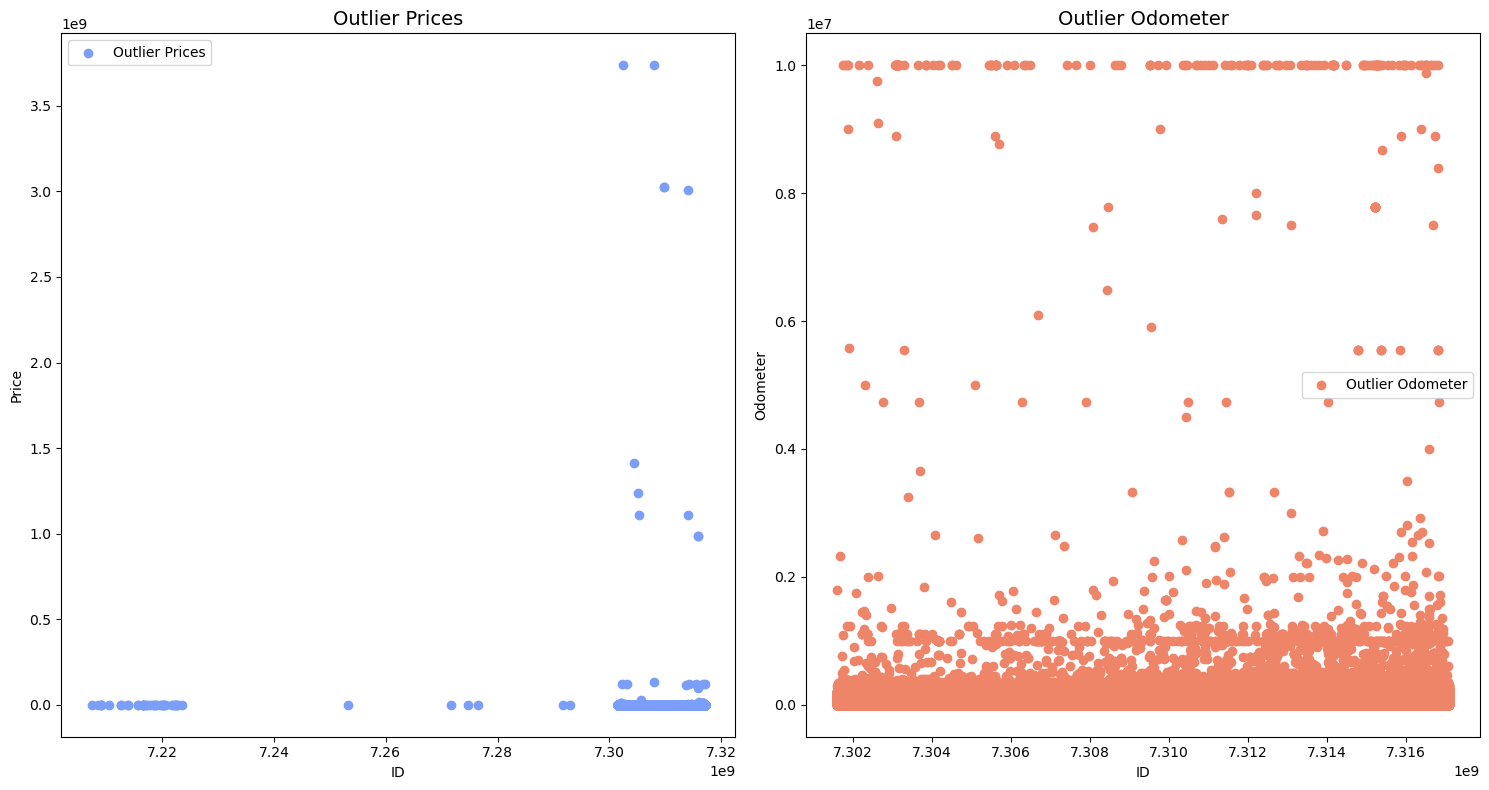

In [246]:
# Function to Visualize 
def visualize_outliers(ids, prices, odometers):
    """
    Plots outlier visualization using Parameters:
    ids (array-like): ID values
    prices (array-like): Price values
    odometers (array-like): Odometer values
    """
    colors = cm.coolwarm([0.2, 0.8])  # Coolwarm shades
    fig, axes = plt.subplots(1, 2, figsize=(15, 8))

    # Price Outliers
    axes[0].scatter(ids, prices, color=colors[0], marker='o', label='Outlier Prices')
    axes[0].set_title('Outlier Prices', fontsize=14)
    axes[0].set_xlabel('ID')
    axes[0].set_ylabel('Price')
    axes[0].legend()

    # Odometer Outliers
    axes[1].scatter(ids, odometers, color=colors[1], marker='o', label='Outlier Odometer')
    axes[1].set_title('Outlier Odometer', fontsize=14)
    axes[1].set_xlabel('ID')
    axes[1].set_ylabel('Odometer')
    axes[1].legend()

    plt.tight_layout()
    plt.show()
    
visualize_outliers(data['id'], data['price'], data['odometer'])


### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

In [248]:
def clean_used_car_data(data):
    # Step 1: Fill missing 'year' with the mode
    data['year'] = data['year'].fillna(data['year'].mode()[0]).astype(int)

    #Step 2: Fill with appropriate values that have large percentage of null data
    data.cylinders.fillna('other', inplace = True)
    # fwd is common drive type
    data.drive.fillna('fwd', inplace = True)
    #Fair condition is average value
    data.condition.fillna('fair', inplace = True)
        

    # Step 2.1: Replace nulls with 'NA' for key categorical features that have low percentage of null data
    key_features = ['fuel', 'transmission', 'manufacturer', 'model', 'type', 'paint_color', 'title_status']
    data[key_features] = data[key_features].fillna("NA")

    # Step 3: Remove cars with old manufacturing years
    data = data[data['year'] >= 1980]

    # Step 4: Remove price and odometer outliers
    data = data[(data['price'] > 1000) & (data['price'] < 100000)]
    data = data[(data['odometer'] > 0) & (data['odometer'] < 500000)]

    # Step 5 & 6: Drop rows with missing price/odometer since these cannot be null or replaced with appropriate data
    data = data[data['price'].notnull()]
    data = data[data['odometer'].notnull()]
    data = data[data['size'].notnull()]

    # Step 7: Drop 'VIN' column as its not required for modeling
    data.drop('VIN', axis=1, inplace=True, errors='ignore')

    # Step 8: Clean and standardize the 'model' column
    data['model'] = (
        data['model']
        .fillna('unknown')
        .str.lower()
        .str.replace(r'[^a-z0-9]', '', regex=True)
    )

    # Step 9: Group less common models into 'other' category
    top_models = data['model'].value_counts().nlargest(100).index
    data['model'] = data['model'].apply(lambda x: x if x in top_models else 'other')
    return data

cleaned_data = clean_used_car_data(data)
cleaned_data.head(10)

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,paint_color,state
31,7316356412,auburn,15000,2013,ford,f150xlt,excellent,6 cylinders,gas,128000.0,clean,automatic,rwd,full-size,truck,black,al
55,7314560853,auburn,19900,2004,ford,f250superduty,good,8 cylinders,diesel,88000.0,clean,automatic,4wd,full-size,pickup,blue,al
59,7313406529,auburn,14000,2012,honda,odyssey,excellent,6 cylinders,gas,95000.0,clean,automatic,fwd,full-size,mini-van,silver,al
65,7312847466,auburn,22500,2001,ford,other,good,8 cylinders,diesel,144700.0,clean,manual,rwd,full-size,truck,white,al
73,7312144944,auburn,15000,2017,dodge,other,excellent,8 cylinders,gas,90000.0,rebuilt,automatic,rwd,mid-size,sedan,grey,al
86,7310644616,auburn,3000,2004,chrysler,towncountry,good,6 cylinders,gas,176144.0,clean,automatic,fwd,mid-size,mini-van,silver,al
110,7307730503,auburn,9500,2003,chrysler,towncountry,excellent,6 cylinders,gas,30376.0,clean,automatic,fwd,mid-size,mini-van,blue,al
119,7306407989,auburn,17500,2008,toyota,other,good,6 cylinders,gas,201300.0,clean,manual,4wd,full-size,offroad,black,al
122,7306198330,auburn,6800,2005,NA,other,excellent,6 cylinders,diesel,180000.0,clean,automatic,rwd,full-size,bus,yellow,al
138,7304785580,auburn,4000,2006,jeep,other,good,6 cylinders,gas,281000.0,clean,automatic,rwd,mid-size,SUV,black,al


In [249]:
# Display shape and preview
print("Cleaned data shape:",cleaned_data.shape)
describe_columns(cleaned_data)

Cleaned data shape: (102513, 17)


,Null Count,Non-Null Count,% Null,Unique Values,Min,Max,25%,50%,75%
id,0,102513,0.0,102513,"7,301,586,982","7,317,101,084","7,308,644,554","7,313,082,672","7,315,338,588"
odometer,0,102513,0.0,37837,1,"499,232","69,634","111,000","152,696"
paint_color,0,102513,0.0,13,NaN,NaN,NaN,NaN,NaN
type,0,102513,0.0,14,NaN,NaN,NaN,NaN,NaN
size,0,102513,0.0,4,NaN,NaN,NaN,NaN,NaN
drive,0,102513,0.0,3,NaN,NaN,NaN,NaN,NaN
transmission,0,102513,0.0,4,NaN,NaN,NaN,NaN,NaN
title_status,0,102513,0.0,7,NaN,NaN,NaN,NaN,NaN
fuel,0,102513,0.0,6,NaN,NaN,NaN,NaN,NaN
region,0,102513,0.0,404,NaN,NaN,NaN,NaN,NaN


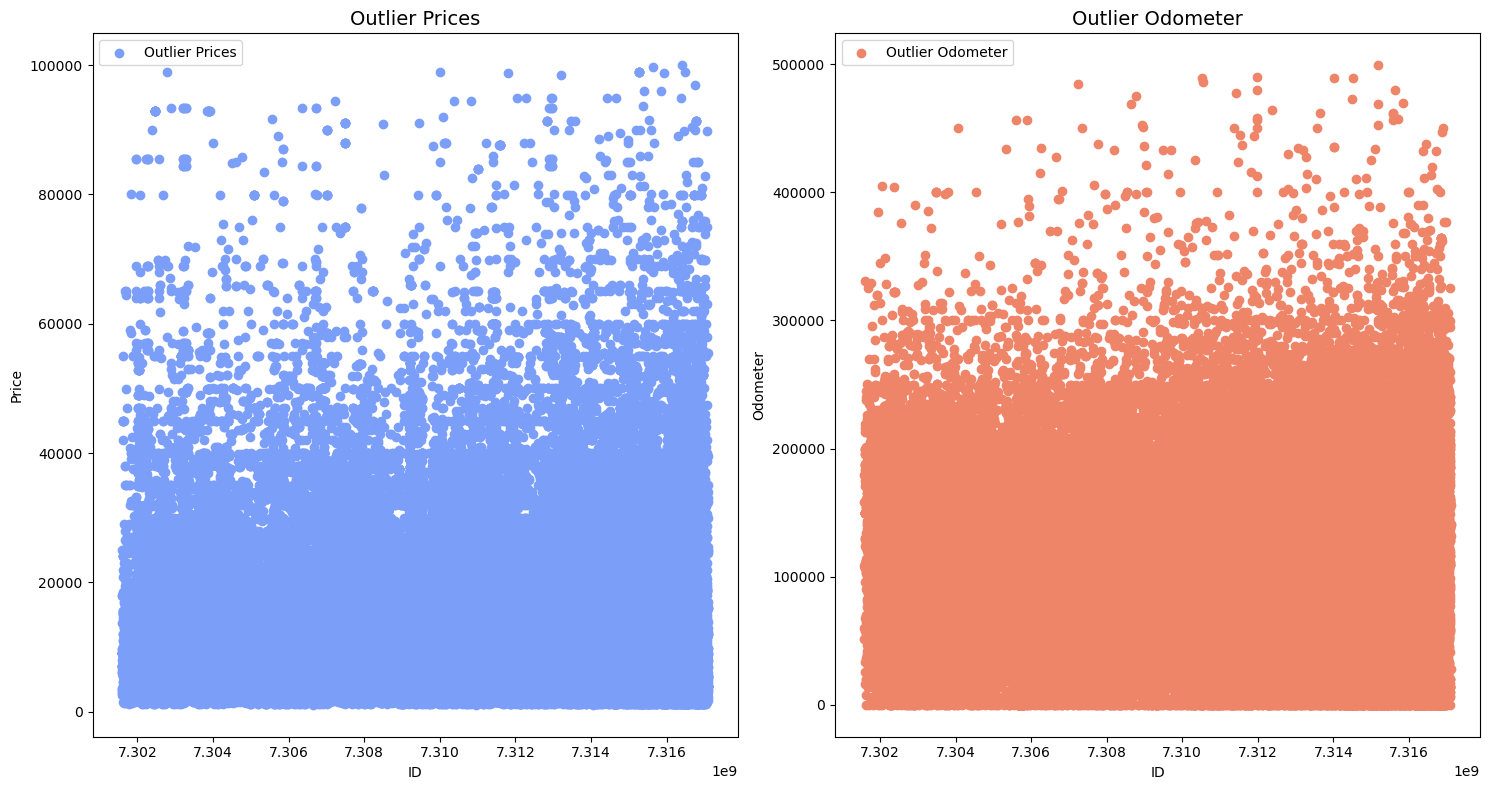

In [250]:
visualize_outliers(cleaned_data['id'], cleaned_data['price'], cleaned_data['odometer'])

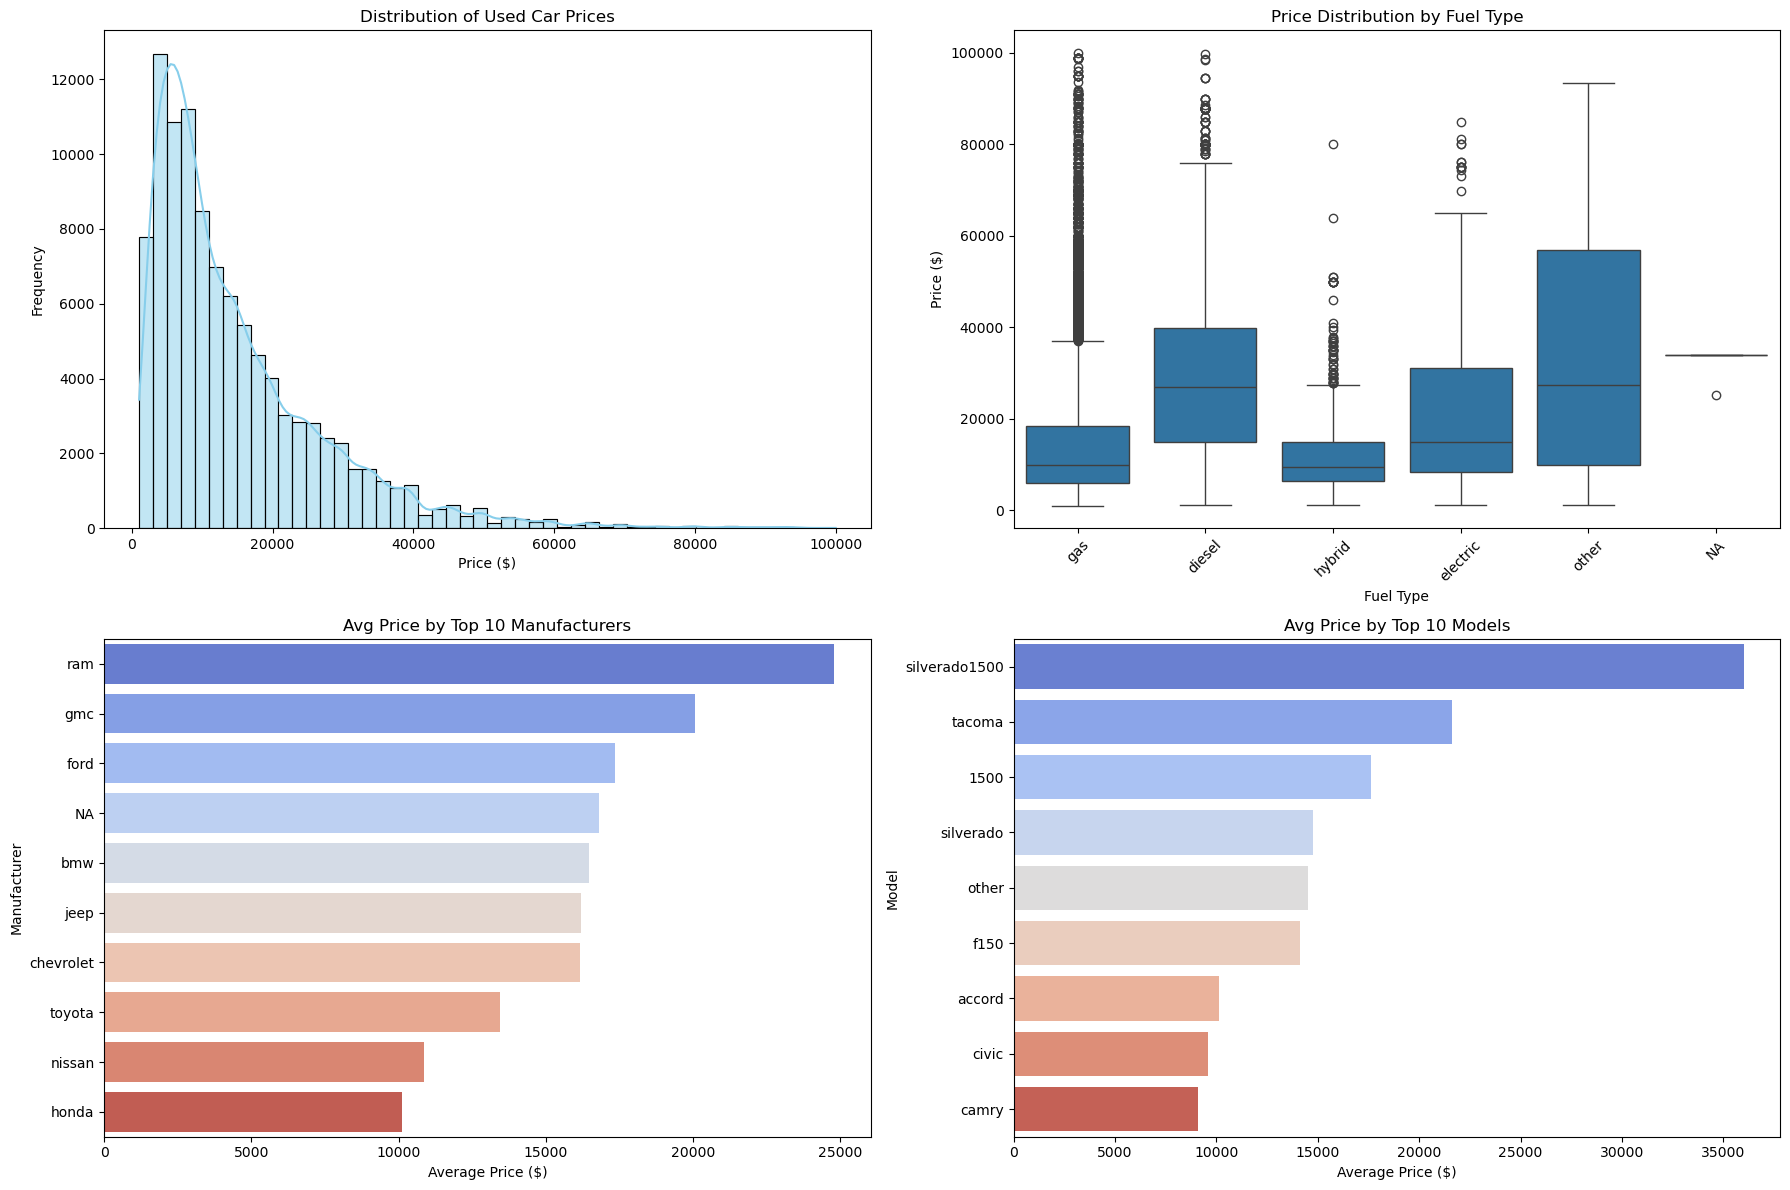

In [252]:
# further visualize using subplots

# Create 2x2 subplot
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

sns.histplot(cleaned_data['price'], bins=50, kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set(title="Distribution of Used Car Prices", xlabel="Price ($)", ylabel="Frequency")

# Plot 2: Boxplot of price by fuel type
sns.boxplot(x='fuel', y='price', data=cleaned_data, ax=axes[0, 1])
axes[0, 1].set(title="Price Distribution by Fuel Type", xlabel="Fuel Type", ylabel="Price ($)")
axes[0, 1].tick_params(axis='x', rotation=45)

# Top 10 manufacturers by volume
top_10_makes = cleaned_data['manufacturer'].value_counts().nlargest(10).index
avg_price_by_make = cleaned_data[cleaned_data['manufacturer'].isin(top_10_makes)].groupby('manufacturer')['price'].mean().sort_values(ascending=False)

# Top 10 models
top_10_models = cleaned_data['model'].value_counts().nlargest(10).index
avg_price_by_model = cleaned_data[data['model'].isin(top_10_models)].groupby('model')['price'].mean().sort_values(ascending=False)

# Plot 1: Histogram of price distribution
# Plot 3: Avg price by top 10 manufacturers
sns.barplot(x=avg_price_by_make.values, y=avg_price_by_make.index, ax=axes[1, 0], palette="coolwarm")
axes[1, 0].set(title="Avg Price by Top 10 Manufacturers", xlabel="Average Price ($)", ylabel="Manufacturer")

# Plot 4: Avg price by top 10 models
sns.barplot(x=avg_price_by_model.values, y=avg_price_by_model.index, ax=axes[1, 1], palette="coolwarm")
axes[1, 1].set(title="Avg Price by Top 10 Models", xlabel="Average Price ($)", ylabel="Model")

plt.tight_layout()
plt.show()


Observations:

1) Price Distribution: Most used cars fall between 5K and 25K.
2) Price by Fuel Type:Diesel and hybrid fuel tend to have higher prices. Gas is the most common and spans a wide price range.
3) Electric vehciles are fewer in count but higher in value.
4) Truck, SUV models like Tacoma, Silerado1500, 4runner hold stronger value.

In [258]:
# Apply One Hot Encoding on Categorical Columns
encode_cols = ['condition', 'cylinders', 'fuel', 'drive', 'transmission', 'type', 'size', 'paint_color', 'title_status']
data_encoded = pd.get_dummies(cleaned_data, columns=encode_cols, drop_first=True)

data_encoded.head()

,id,region,price,year,manufacturer,model,odometer,state,condition_fair,condition_good,...,paint_color_red,paint_color_silver,paint_color_white,paint_color_yellow,title_status_clean,title_status_lien,title_status_missing,title_status_parts only,title_status_rebuilt,title_status_salvage
31,7316356412,auburn,15000,2013,ford,f150xlt,128000.0,al,False,False,...,False,False,False,False,True,False,False,False,False,False
55,7314560853,auburn,19900,2004,ford,f250superduty,88000.0,al,False,True,...,False,False,False,False,True,False,False,False,False,False
59,7313406529,auburn,14000,2012,honda,odyssey,95000.0,al,False,False,...,False,True,False,False,True,False,False,False,False,False
65,7312847466,auburn,22500,2001,ford,other,144700.0,al,False,True,...,False,False,True,False,True,False,False,False,False,False
73,7312144944,auburn,15000,2017,dodge,other,90000.0,al,False,False,...,False,False,False,False,False,False,False,False,True,False


In [260]:
# Apply Label Ecoding on NON-categorical Column

label_encode_cols = ['region', 'manufacturer', 'model', 'state']

for x in label_encode_cols:
    data_encoded[x + '_encoded'] = LabelEncoder().fit_transform(data_encoded[x])

# Select only numeric columns from the Encoded column
data_model_ready = data_encoded.select_dtypes(exclude=['object'])

#<------ FINAL DATASET READY for Modeling------->#
data_model_ready.info() 
#-----------------------------------------------#

<class 'pandas.core.frame.DataFrame'>
Index: 102513 entries, 31 to 426833
Data columns (total 64 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       102513 non-null  int64  
 1   price                    102513 non-null  int64  
 2   year                     102513 non-null  int64  
 3   odometer                 102513 non-null  float64
 4   condition_fair           102513 non-null  bool   
 5   condition_good           102513 non-null  bool   
 6   condition_like new       102513 non-null  bool   
 7   condition_new            102513 non-null  bool   
 8   condition_salvage        102513 non-null  bool   
 9   cylinders_12 cylinders   102513 non-null  bool   
 10  cylinders_3 cylinders    102513 non-null  bool   
 11  cylinders_4 cylinders    102513 non-null  bool   
 12  cylinders_5 cylinders    102513 non-null  bool   
 13  cylinders_6 cylinders    102513 non-null  bool   
 14  cylinder

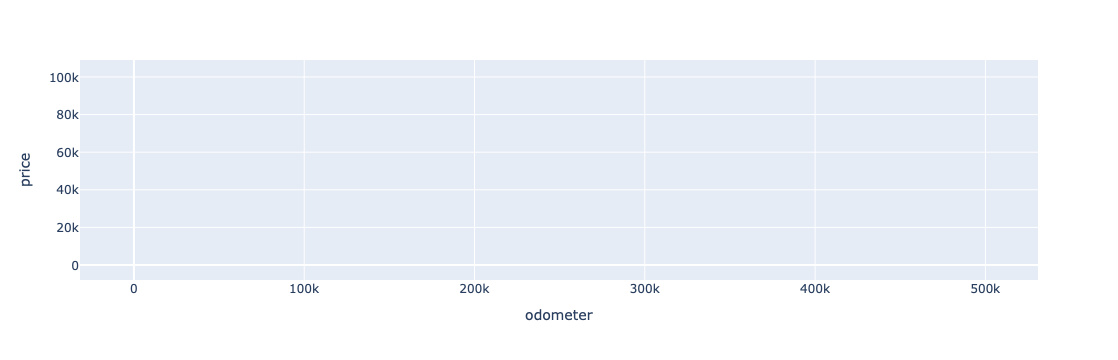

In [262]:
# Inverse Relationship Between Odometer and Price.

px.scatter(data_frame=data_model_ready, x='odometer', y='price')  

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [265]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
model = LinearRegression().fit(X_train, y_train)

# Top Features
N = 20
top_features = (
    pd.DataFrame({'feature': X.columns, 'coefficient': model.coef_})
    .assign(abs_coef=lambda df: df['coefficient'].abs())
    .sort_values(by='abs_coef', ascending=False)
    .head(N)
)
top_features

,feature,coefficient,abs_coef
0,year,0.382467,0.382467
1,odometer,-0.296044,0.296044
9,cylinders_4 cylinders,-0.242763,0.242763
11,cylinders_6 cylinders,-0.173208,0.173208
52,title_status_clean,-0.146226,0.146226
19,drive_fwd,-0.144598,0.144598
56,title_status_rebuilt,-0.142653,0.142653
34,type_truck,0.116786,0.116786
57,title_status_salvage,-0.109342,0.109342
16,fuel_gas,-0.092014,0.092014


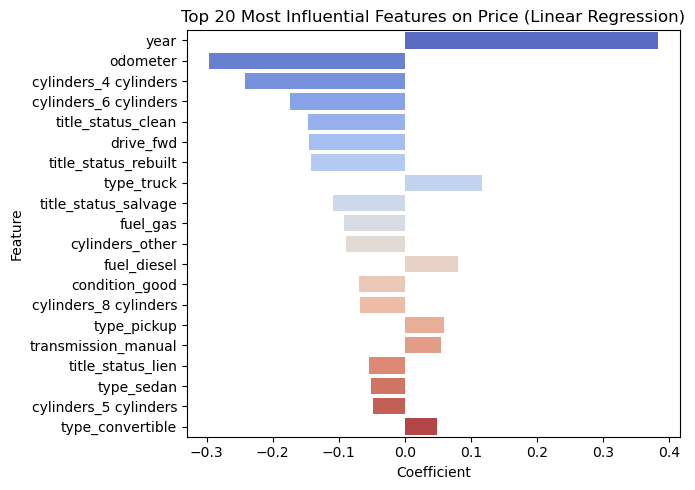

In [267]:
#Visualize

plt.figure(figsize=(7, 5))
sns.barplot(x='coefficient', y='feature', data=top_features, palette='coolwarm')
plt.title('Top 20 Most Influential Features on Price (Linear Regression)')
plt.xlabel('Coefficient')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [269]:
# Multi Linear Regression

# 1. Define Features and Target
y = data_model_ready['price']

# Drop Paint color and title status
X = data_model_ready.drop(columns=[ 'price', 'id' ])

# 2. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train the Model
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Make Predictions
y_pred = model.predict(X_test)

# 5. Evaluate Performance directly on original price
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")


RMSE: 7142.56
R² Score: 0.6592


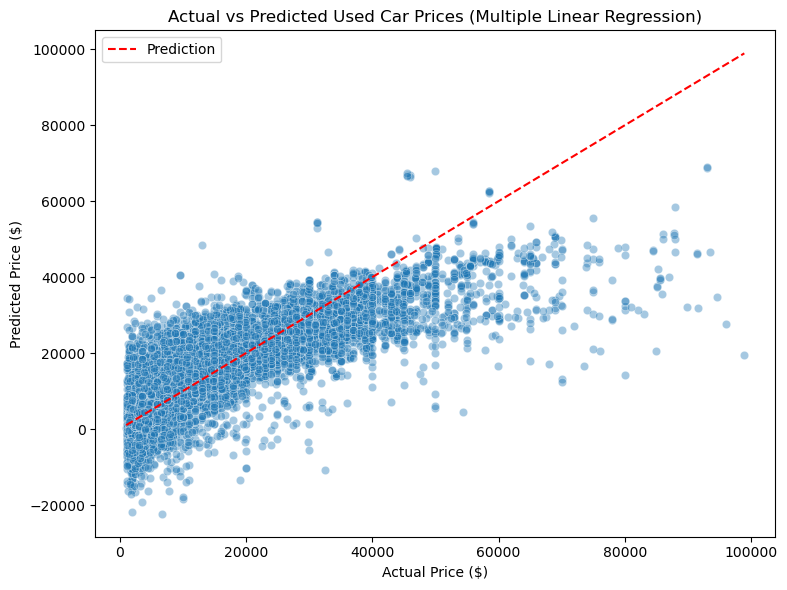

In [271]:

# Scatter plot: Actual vs Predicted
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Prediction')
plt.title("Actual vs Predicted Used Car Prices (Multiple Linear Regression)")
plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.legend()
plt.tight_layout()
plt.show()


In [273]:
#Ridge with Grid Search CV

# Define target
y = data_model_ready['price']

#select top features from the above list 
top_feature_names = top_features['feature'].tolist() 

# subset with top feature names
X_top = data_model_ready[top_feature_names]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_top, y, test_size=0.2, random_state=42)


In [275]:
pipeline_upgraded = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)), 
    ('ridge', Ridge())
])

In [277]:
param_grid = {
    'ridge__alpha': [0.001, 0.01, 0.1, 1, 10, 100, 500, 1000]
}

grid_search = GridSearchCV(pipeline_upgraded,
                           param_grid,
                           cv=5,
                           scoring='neg_root_mean_squared_error',
                           n_jobs=-1)

In [279]:
warnings.filterwarnings("ignore")

grid_search.fit(X_train, y_train)

print("Best Ridge alpha:", grid_search.best_params_['ridge__alpha'])

y_pred = grid_search.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")

Best Ridge alpha: 100
RMSE: 5965.13
R²: 0.7623


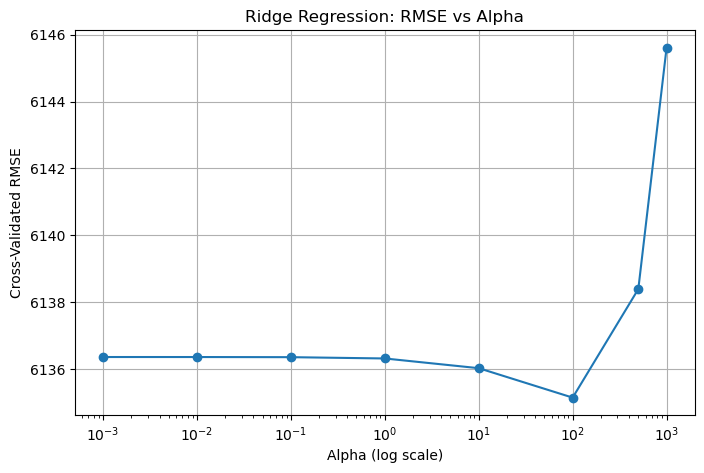

In [155]:
#Visualize

# Extract results from GridSearchCV
results = grid_search.cv_results_
alphas = results['param_ridge__alpha'].data  
scores = -results['mean_test_score']         

# Plot RMSE vs Alpha
plt.figure(figsize=(8, 5))
plt.plot(alphas, scores, marker='o')
plt.xscale('log')
plt.title("Ridge Regression: RMSE vs Alpha")
plt.xlabel("Alpha (log scale)")
plt.ylabel("Cross-Validated RMSE")
plt.grid(True)
plt.show()


In [281]:
# Lasso Model
# Define target
y = data_model_ready['price']

#select top features from the above list 
top_feature_names = top_features['feature'].tolist() 

# subset with top feature names
X_top = data_model_ready[top_feature_names]

# Train/test split
Xl_train, Xl_test, yl_train, yl_test = train_test_split(X_top, y, test_size=0.2, random_state=42)


In [283]:
# Define the Lasso pipeline
pipeline_lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(max_iter=5000))  
])


In [285]:
#Set the hyperparameter grid for alpha tuning
param_grid = {
    'lasso__alpha': [0.001, 0.01, 0.1, 1, 10, 100]
}


In [287]:
# Grid Search
grid_search = GridSearchCV(pipeline_lasso,
                           param_grid,
                           cv=5,
                           scoring='neg_root_mean_squared_error',
                           n_jobs=-1)

# Train the model
warnings.filterwarnings("ignore")

#Fit Model
grid_search.fit(Xl_train, yl_train)

print("Best Lasso alpha:", grid_search.best_params_['lasso__alpha'])


Best Lasso alpha: 0.1


In [289]:
##### Predict Model
yl_pred = grid_search.predict(Xl_test)
#RMSE and R2
rmse = mean_squared_error(yl_test, yl_pred, squared=False)
r2 = r2_score(yl_test, yl_pred)

print(f" Lasso RMSE: {rmse:.2f}")
print(f" Lasso R² Score: {r2:.4f}")

 Lasso RMSE: 7393.41
 Lasso R² Score: 0.6348


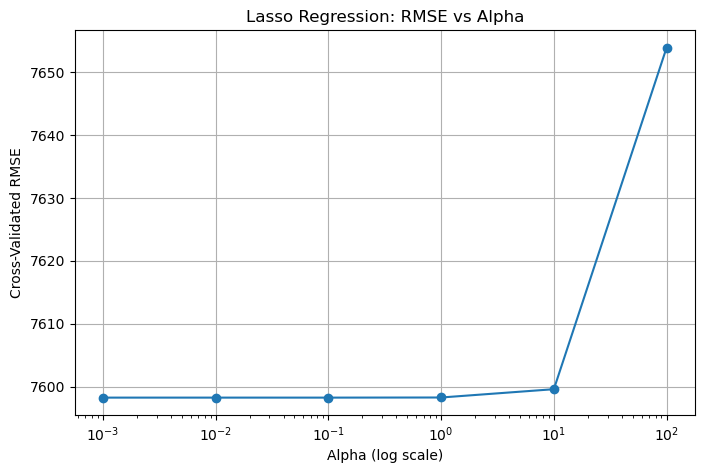

In [291]:
#Visualize Cross Validation Step
results = grid_search.cv_results_
alphas = results['param_lasso__alpha'].data
scores = -results['mean_test_score']

plt.figure(figsize=(8, 5))
plt.plot(alphas, scores, marker='o')
plt.xscale('log')
plt.title("Lasso Regression: RMSE vs Alpha")
plt.xlabel("Alpha (log scale)")
plt.ylabel("Cross-Validated RMSE")
plt.grid(True)
plt.show()


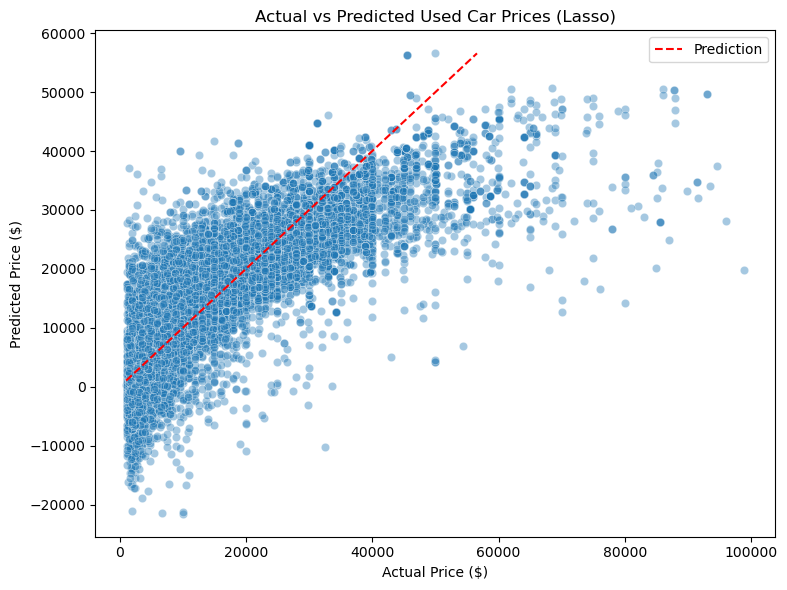

In [184]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=yl_test, y=yl_pred, alpha=0.4)
plt.plot([yl_test.min(), yl_pred.max()],
         [yl_test.min(), yl_pred.max()],
         'r--', label='Prediction')
plt.title("Actual vs Predicted Used Car Prices (Lasso)")
plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.legend()
plt.tight_layout()
plt.show()

In [293]:

# Log-transform target
y = np.log1p(data_encoded['price'])

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict and inverse transform
y_pred = model.predict(X_test)
y_pred_actual = np.expm1(y_pred)
y_test_actual = np.expm1(y_test)

# Evaluate
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
r2 = r2_score(y_test_actual, y_pred_actual)

print(f"RMSE (log-transformed): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")


RMSE (log-transformed): 6750.85
R² Score: 0.6955


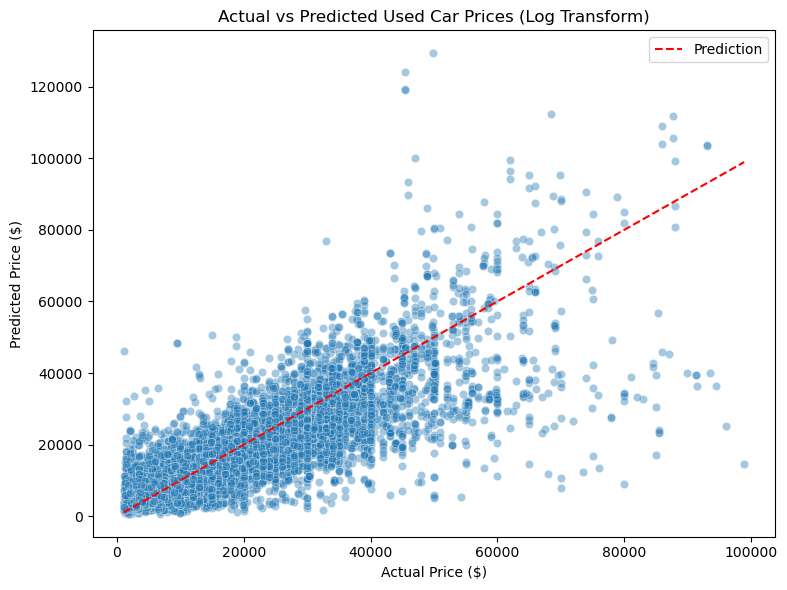

In [295]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_actual, y=y_pred_actual, alpha=0.4)
plt.plot([y_test_actual.min(), y_test_actual.max()],
         [y_test_actual.min(), y_test_actual.max()],
         'r--', label='Prediction')
plt.title("Actual vs Predicted Used Car Prices (Log Transform)")
plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.legend()
plt.tight_layout()
plt.show()

### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

## **Model Comparison Summary**

| Model                             | RMSE ($) | R² Score | Notes |
|----------------------------------|----------|----------|-----------------------------|
| **Ridge Regression (α=100)**     | 5,965.13 | 0.7623   | BEST overall performer: low error, high explanatory power |
| Multiple Linear Regression (raw) | 7,142.56 | 0.6592   | Reliable baseline model, no regularization but not as precise |
| Log-Transformed Linear Regression| 6,750.85 | 0.6955   | Normalized price improves performance, but not best |
| Lasso Regression                 | 7,393.41 | 0.6348   | Underfit — too much regularization, Not the best choice for prediction |



### Key Insights from Modeling

- **Ridge Regression** performed best due to its ability to manage multicollinearity and handle scaled and encoded features.
- **Year** **Odometer** and **Condition** of the vehicle are major drivers:  
  - Newer Car with 0 miles or minimally driven used car has more price value 
  - Higher mileage reduces price  
  - Better condition significantly increases the price of the used vehicle
- **Title status** has a massive impact:  
  - Salvage, rebuilt, and parts-only titles can reduce price by over **$25,000**
- **Fuel type** and **vehicle type** matter:  
  - **Diesel engines** and **trucks** retain value better than economy or base models

---




### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

RESPONSE: Findings from the analysis for the car dealership:

**Objective**: Help dealerships optimize pricing and inventory based on data-driven insights.

**Summary** I developed a set of machine learning models to predict used car prices and identified best features that impact the used car re-sale value. The best-performing model, **Ridge Regression**, achieved an RMSE of **$5,965** and an R² score of **0.7623**, meaning it explains over **76 percent** of price variation. 

In other words, the model can predict the used car prices with an average error of just **~$5,965**, and it explains over **76 percent** of what causes price differences between vehicles.

This model is accurate, stable, and ready to support real-world pricing decisions. I recommend implementing this as the primary pricing engine for the used car for a dealership. These insights enable dealers to better price inventory, avoid overpaying for undervalued vehicles, and source vehicles that are in high demand.


## Top 20 Influential Features Driving Used Car Prices ##

Also, these coefficients are derived from a standardized linear regression model. Positive values increase the predicted price, while negative values reduce it.

| Positive Influencers     | Coefficient | Interpretation |
|--------------------------|-------------|----------------|
| `year`                   | +0.382      | Newer cars are priced higher |
| `fuel_diesel`            | +0.080      | Diesel vehicles are more valuable |
| `type_truck`             | +0.117      | Trucks retain better resale value |
| `type_pickup`            | +0.059      | Pickups tend to retain resale value |
| `transmission_manual`    | +0.054      | Attracts enthusiast buyers which boosts value |
| `type_convertible`       | +0.048      | Niche luxury/lifestyle appeal increases value |


| Negative Influencers     | Coefficient | Interpretation |
|--------------------------|-------------|----------------|
| `odometer`               | -0.296      | Higher the mileage lower the re-sale value |
| `cylinders_4 cylinders`  | -0.243      | Economy engines reduce car price |
| `cylinders_6 cylinders`  | -0.173      | Mid-range engines slightly lower price |
| `drive_fwd`              | -0.145      | FWD is mostly in economy segment vehicles |
| `title_status_rebuilt`   | -0.143      | Rebuilt title significantly lowers value |
| `title_status_salvage`   | -0.109      | Major negative imp